# 03 BMRA

Run BMRA based on global responses derived from the pathway activity predictions.

In [1]:
import pandas as pd
import numpy as np
import os
import bmra

In [2]:
cell_line = 'BC3C'

data_dir =f'/home/jing/Phd_project/project_UCD_blca/blca_publication_OUTPUT/blca_publication_OUTPUT_bmra/blca_publication_OUTPUT_bmra_{cell_line}_oct/'
data_dir_1 = os.path.join(data_dir, f'00_outputs_2020_{cell_line}/')
data_dir_2 = os.path.join(data_dir, f'01_outputs_2020_{cell_line}/')

info_dir =f"/home/jing/Phd_project/project_UCD_blca/blca_publication_OUTPUT/blca_publication_OUTPUT_LINCS/00_outputs_2020_{cell_line}/"

out_dir = os.path.join(data_dir,f'02_outputs_2020_{cell_line}/')


os.makedirs(out_dir, exist_ok = True)

## Load data

### Global responses

Assembled from global responses calculated from predicted pathway activities, and DPD global responses.

In [3]:
def assemble_R_global(pathway_rglobal_file, dpd_rglobal_file):
    """
    Assemble full R_global matrix
    """
    R_global_modules_df = pd.read_csv(pathway_rglobal_file, index_col = 0)

    perts = R_global_modules_df.columns.tolist()

    R_global_DPD_df = pd.read_csv(dpd_rglobal_file, index_col=0).T

    # filter by perts list
    R_global_DPD_df = R_global_DPD_df[R_global_DPD_df.index.isin(perts)]

    # sort by perts list
    R_global_DPD_df["sort_col"] = R_global_DPD_df.index.map({val: i for i, val in enumerate(perts)})
    R_global_DPD_df = R_global_DPD_df.sort_values("sort_col")
    R_global_DPD_df = R_global_DPD_df.drop("sort_col", axis = 1)

    # transpose
    R_global_DPD_df = R_global_DPD_df.T

    R_global_df = pd.concat([R_global_modules_df, R_global_DPD_df])

    return R_global_df

In [4]:
R_global_df = assemble_R_global(
    pathway_rglobal_file = os.path.join(data_dir_2, "R_global_annotated.csv"),
    dpd_rglobal_file = os.path.join(data_dir_1, "R_global_DPDonly_annotated.csv"),
)

modules = R_global_df.index.tolist()
exp_ids = R_global_df.columns.tolist()

R_global = R_global_df.values
n_modules = R_global.shape[0]

print(R_global.shape)
display(R_global_df)

(15, 106)


,ASG002_BC3C_24H:A10,ASG002_BC3C_24H:A11,ASG002_BC3C_24H:A19,ASG002_BC3C_24H:A20,ASG002_BC3C_24H:A21,ASG002_BC3C_24H:B10,ASG002_BC3C_24H:B11,ASG002_BC3C_24H:B14,ASG002_BC3C_24H:B15,ASG002_BC3C_24H:C13,...,MOAR011_BC3C_24H:C02,MOAR011_BC3C_24H:C03,MOAR011_BC3C_24H:C10,MOAR011_BC3C_24H:C11,MOAR011_BC3C_24H:F07,MOAR011_BC3C_24H:F08,MOAR011_BC3C_24H:F09,MOAR011_BC3C_24H:J10,TGFbRin,SMAD3in
Androgen,-0.052621,-0.009990,0.001874,-0.039472,0.001324,0.019733,0.004206,0.016562,0.020893,0.035649,...,-0.001679,-0.009316,-0.053252,-0.005367,-0.055305,0.028579,0.026119,-0.585968,-0.009139,0.006162
CDK1_2,-0.621082,-0.531031,0.093002,-0.056078,0.080421,-0.266776,0.049598,-0.323796,0.120332,0.070655,...,-0.140913,0.049986,-0.114174,0.012147,-0.807172,0.122808,-0.042203,0.057063,-0.041460,-0.484842
CDK4_6,-0.024936,-0.233707,-0.041751,-0.514436,0.040579,0.002081,-0.008150,0.097358,0.086051,0.031921,...,0.097750,-0.089140,-1.036780,-1.207947,0.318628,0.199218,-0.063101,-0.014375,0.243961,-0.735755
EGFR,0.595317,0.495997,0.227641,0.366392,0.491113,0.114004,-0.413685,0.264438,0.284352,-0.045713,...,-0.056304,-0.035652,-0.086204,-0.423370,-0.437931,-0.554481,-0.316714,-0.228032,-0.240228,-0.852414
Estrogen,-0.123581,-0.206520,-0.210390,-0.408850,-0.948934,-0.310324,-0.086625,-0.236793,-0.163154,-0.040838,...,0.039947,-0.011210,0.023137,0.134809,-1.511066,-0.227770,0.183108,-0.253387,0.095644,-0.273029
FGFR,-0.110826,-0.176615,-0.089973,0.051372,-0.028303,-0.407054,-0.033356,-0.026203,-0.061578,-0.300794,...,0.048645,-0.023038,0.027171,-0.236077,-0.548053,0.023803,0.222081,0.037442,-0.276134,-0.698995
PI3K,-1.905384,-1.706779,-1.427511,-1.235968,-0.703423,0.292413,-0.145389,-0.189694,-0.848614,-0.279918,...,-0.047315,-0.516501,-0.513706,0.010704,-0.832753,0.221675,-0.238456,0.010389,-0.018707,-0.094551
p53,-0.208180,-0.220330,-0.126568,-0.402443,0.054129,-1.629256,-1.474548,-0.119131,-0.085082,-1.327909,...,0.027714,0.239815,0.203075,0.280463,-0.227430,-0.049061,0.029911,0.600581,0.065568,0.164890
TOP2A,-0.225857,0.074982,-0.234867,-0.172053,-0.126895,0.054219,0.071537,-1.999303,-0.205636,-0.288424,...,0.077445,-0.176942,-0.523301,0.050593,-0.750866,-0.009134,-0.032931,-0.440533,0.246082,0.134996
Src,-0.930922,-1.681221,0.523029,-1.207023,0.571560,-1.128624,0.495749,0.394395,0.396866,0.447353,...,0.060890,0.062826,-0.104232,-0.013038,0.039772,0.245412,0.777845,-0.155845,-0.153134,-0.069255


In [5]:
print(R_global_df.values.min())
print(R_global_df.values.max())

-141.3271606788109
23.679038382410333


### Perturbation matrix

In [6]:
inhib_conc_df = pd.read_csv(os.path.join(data_dir_1, "inhib_conc_annotated.csv"), index_col = 0)
#LFC_PLCg = pd.read_csv(os.path.join(info_dir,"PLCg_Data_log_2020.csv"),index_col=0)
#inhib_conc = inhib_conc_df.drop(columns=LFC_PLCg.index).values
inhib_conc = inhib_conc_df.values

n_DPDs = R_global.shape[0] - inhib_conc.shape[0]

pert_modules = np.where(inhib_conc != 0, 1, 0)
pert_DPD = np.zeros((n_DPDs, len(exp_ids)))

pert = np.vstack([pert_modules, pert_DPD])

print(pert.shape)
print(pert)

(15, 106)
[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### Networks

In [7]:
# empty prior
#G_prior = np.zeros((n_modules, n_modules))
G_prior_df = pd.read_excel(os.path.join(info_dir, "ALL_DATA_2020_oct25.xlsx"), sheet_name = "prior_net_work", index_col = 0)

G_prior = G_prior_df.values
G_prior_df

,CDK1_2,CDK4_6,EGFR,PI3K,FGFR,TOP2A,p53,Src,TGFb,Estrogen,Androgen,SMAD3,blca_inv,blca_onc,surv_coef
CDK1_2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
CDK4_6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
EGFR,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
PI3K,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
FGFR,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
TOP2A,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
p53,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Src,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
TGFb,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Estrogen,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
#G_prior_r_df = pd.read_excel(os.path.join(info_dir, "ALL_DATA_2020.xlsx"), sheet_name = "prior_r", index_col = 0)

#G_prior_r = G_prior_r_df.values
#G_prior_r_df

In [9]:
G_not = np.eye(n_modules)
G_not[:, n_modules - n_DPDs :] = 1

G_not

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0.

## Run BMRA

In [10]:
n_gibbs = 200_000
n_window = 5_000

mode = "all"
n_iterations = 1

In [11]:
A_mean, A_sd, r_mean, r_sd = bmra.run_bmra(R_global,
            pert,
            G_prior,
            G_not,
            #r_prior = G_prior_r,
            n_gibbs = n_gibbs,
            n_window = n_window,
            mode = mode,
            n_iterations = n_iterations,
        )

A_mean_df = pd.DataFrame(A_mean, index = modules, columns = modules)
A_sd_df = pd.DataFrame(A_sd, index = modules, columns = modules)
r_mean_df = pd.DataFrame(r_mean, index = modules, columns = modules)
r_sd_df = pd.DataFrame(r_sd, index = modules, columns = modules)

display(A_mean_df)
display(A_sd_df)
display(r_mean_df)
display(r_sd_df)

A_mean_df.to_csv(os.path.join(out_dir, "A_mean.csv"))
A_sd_df.to_csv(os.path.join(out_dir, "A_sd.csv"))
r_mean_df.to_csv(os.path.join(out_dir, "r_mean.csv"))
r_sd_df.to_csv(os.path.join(out_dir, "r_sd.csv"))

,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.0,0.000000,0.000000,1.0000,0.000000,0.000000,0.002117,0.000000,0.000000,0.000791,0.0,0.0,0.0,0.0,0.0
CDK1_2,0.0,0.000000,0.008071,0.9547,0.000000,0.821895,1.000000,0.000000,0.000000,0.289173,0.0,0.0,0.0,0.0,0.0
CDK4_6,0.0,0.000000,0.000000,1.0000,0.000000,0.000000,1.000000,0.000000,0.000000,0.198458,0.0,0.0,0.0,0.0,0.0
EGFR,0.0,0.000000,1.000000,0.0000,0.000000,0.926035,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Estrogen,0.0,0.000000,0.000000,0.0000,0.000000,1.000000,1.000000,0.000000,0.000000,0.386823,0.0,0.0,0.0,0.0,0.0
FGFR,0.0,0.000000,0.026229,1.0000,0.061945,0.000000,0.971503,0.845373,0.000000,0.009488,0.0,0.0,0.0,0.0,0.0
PI3K,0.0,1.000000,0.000000,1.0000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0.0,0.0,0.0
p53,0.0,0.001942,0.000758,1.0000,0.000710,0.001139,0.869298,0.000000,0.030339,0.001001,0.0,0.0,0.0,0.0,0.0
TOP2A,0.0,0.000000,0.000000,1.0000,0.016651,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Src,0.0,0.000000,0.000000,1.0000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.0,0.000000e+00,0.000000e+00,1.776357e-15,0.000000e+00,0.000000e+00,4.596071e-02,0.000000e+00,0.000000e+00,0.028108,0.0,0.0,0.0,0.0,0.0
CDK1_2,0.0,0.000000e+00,8.947721e-02,2.079623e-01,0.000000e+00,3.826014e-01,3.996803e-15,0.000000e+00,0.000000e+00,0.453378,0.0,0.0,0.0,0.0,0.0
CDK4_6,0.0,0.000000e+00,0.000000e+00,1.998401e-15,0.000000e+00,0.000000e+00,1.998401e-15,0.000000e+00,0.000000e+00,0.398839,0.0,0.0,0.0,0.0,0.0
EGFR,0.0,0.000000e+00,1.554312e-15,0.000000e+00,0.000000e+00,2.617143e-01,1.554312e-15,0.000000e+00,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0
Estrogen,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.771561e-16,7.771561e-16,0.000000e+00,0.000000e+00,0.487023,0.0,0.0,0.0,0.0,0.0
FGFR,0.0,0.000000e+00,1.598163e-01,1.776357e-15,2.410556e-01,0.000000e+00,1.663879e-01,3.615485e-01,0.000000e+00,0.096943,0.0,0.0,0.0,0.0,0.0
PI3K,0.0,1.110223e-15,0.000000e+00,1.110223e-15,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.110223e-15,0.000000,0.0,0.0,0.0,0.0,0.0
p53,0.0,4.403097e-02,2.752960e-02,8.881784e-16,2.664111e-02,3.373686e-02,3.370744e-01,0.000000e+00,1.715184e-01,0.031618,0.0,0.0,0.0,0.0,0.0
TOP2A,0.0,0.000000e+00,0.000000e+00,1.110223e-15,1.279603e-01,0.000000e+00,1.110223e-15,0.000000e+00,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0
Src,0.0,0.000000e+00,0.000000e+00,2.775558e-15,2.775558e-15,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.0,0.000000,0.000000,-0.045685,0.000000,0.000000,0.000020,0.000000,0.000000,7.515499e-07,0.0,0.0,0.0,0.0,0.0
CDK1_2,0.0,0.000000,0.001165,0.152190,0.000000,0.149464,0.237045,0.000000,0.000000,2.358275e-02,0.0,0.0,0.0,0.0,0.0
CDK4_6,0.0,0.000000,0.000000,0.382667,0.000000,0.000000,0.150658,0.000000,0.000000,1.698734e-02,0.0,0.0,0.0,0.0,0.0
EGFR,0.0,0.000000,0.213246,0.000000,0.000000,0.201551,-0.300184,0.000000,0.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0
Estrogen,0.0,0.000000,0.000000,0.000000,0.000000,0.271996,0.138903,0.000000,0.000000,3.411018e-02,0.0,0.0,0.0,0.0,0.0
FGFR,0.0,0.000000,0.003932,0.377743,0.012108,0.000000,0.133748,0.108073,0.000000,5.183684e-04,0.0,0.0,0.0,0.0,0.0
PI3K,0.0,0.404411,0.000000,-0.204806,0.000000,0.000000,0.000000,0.000000,0.570272,0.000000e+00,0.0,0.0,0.0,0.0,0.0
p53,0.0,0.000162,0.000008,0.221995,0.000037,0.000065,0.151450,0.000000,0.007511,1.050375e-05,0.0,0.0,0.0,0.0,0.0
TOP2A,0.0,0.000000,0.000000,-0.133707,0.002192,0.000000,0.168088,0.000000,0.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0
Src,0.0,0.000000,0.000000,0.262256,0.537186,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.0,0.000000,0.000000,0.012328,0.000000,0.000000,0.000557,0.000000,0.000000,0.000072,0.0,0.0,0.0,0.0,0.0
CDK1_2,0.0,0.000000,0.013042,0.048421,0.000000,0.078402,0.028778,0.000000,0.000000,0.038447,0.0,0.0,0.0,0.0,0.0
CDK4_6,0.0,0.000000,0.000000,0.021416,0.000000,0.000000,0.015054,0.000000,0.000000,0.035565,0.0,0.0,0.0,0.0,0.0
EGFR,0.0,0.000000,0.050770,0.000000,0.000000,0.075124,0.023639,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Estrogen,0.0,0.000000,0.000000,0.000000,0.000000,0.032050,0.015631,0.000000,0.000000,0.045543,0.0,0.0,0.0,0.0,0.0
FGFR,0.0,0.000000,0.024862,0.039835,0.048468,0.000000,0.037017,0.055244,0.000000,0.005707,0.0,0.0,0.0,0.0,0.0
PI3K,0.0,0.032705,0.000000,0.026522,0.000000,0.000000,0.000000,0.000000,0.038391,0.000000,0.0,0.0,0.0,0.0,0.0
p53,0.0,0.004427,0.000964,0.056538,0.002152,0.002643,0.071990,0.000000,0.044015,0.001082,0.0,0.0,0.0,0.0,0.0
TOP2A,0.0,0.000000,0.000000,0.021874,0.017096,0.000000,0.020246,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Src,0.0,0.000000,0.000000,0.044370,0.064507,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [12]:
np.fill_diagonal(r_mean_df.values,-1)
rm_minus_inv = pd.DataFrame(np.linalg.pinv(r_mean_df),index=r_mean_df.index,columns=r_mean_df.columns)*(-1)
rm_minus_inv.to_csv(os.path.join(out_dir, 'r_minv.csv'))
display(rm_minus_inv)

,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,1.000000e+00,7.053715e-03,-1.254543e-02,-5.866994e-02,-1.394197e-04,-1.080873e-02,1.744241e-02,-1.168127e-03,9.938146e-03,-5.638678e-05,-5.552988e-18,1.190824e-17,-7.848518e-17,7.067608e-17,-2.967071e-17
CDK1_2,-1.755151e-16,1.108707e+00,4.534482e-02,2.026866e-01,1.774005e-02,2.113906e-01,2.687929e-01,2.284554e-02,1.534566e-01,2.763157e-02,-1.481910e-15,2.248369e-15,-3.487622e-17,-1.949139e-16,2.686560e-17
CDK4_6,9.049063e-17,2.301265e-02,1.096703e+00,4.515516e-01,1.179691e-02,9.765981e-02,5.689988e-02,1.055435e-02,3.252767e-02,1.962589e-02,-3.159242e-16,6.121198e-16,9.292651e-17,2.993930e-16,-1.239120e-16
EGFR,-1.923746e-16,-1.541610e-01,2.745825e-01,1.284110e+00,3.064546e-03,2.366077e-01,-3.812091e-01,2.557081e-02,-2.172008e-01,1.256336e-03,1.423647e-16,-2.466237e-16,-5.250970e-19,-1.291851e-16,2.311913e-16
Estrogen,-3.547803e-17,8.135465e-02,2.242950e-02,9.900766e-02,1.024102e+00,3.106682e-01,2.011548e-01,3.357472e-02,1.149651e-01,3.739329e-02,-6.191391e-16,1.076517e-15,3.826219e-17,1.268240e-16,-9.687205e-17
FGFR,2.863510e-16,2.091070e-02,1.051366e-01,4.725824e-01,1.523140e-02,1.102526e+00,5.165878e-02,1.191528e-01,3.035445e-02,3.371434e-03,-1.120013e-15,2.119782e-15,-9.513436e-18,2.863143e-16,3.618570e-16
PI3K,-1.330398e-16,5.439427e-01,-6.504151e-02,-3.083729e-01,8.398216e-03,2.143155e-02,1.345024e+00,2.316163e-03,7.670467e-01,1.202038e-02,-2.152991e-15,3.692699e-15,-2.100609e-18,-4.479694e-17,-1.896495e-16
p53,-2.197731e-16,4.918418e-02,5.077270e-02,2.367613e-01,2.024497e-03,5.568731e-02,1.212159e-01,1.006018e+00,7.668172e-02,2.130881e-03,-4.726428e-16,5.731251e-16,-3.762211e-17,-4.807665e-16,-2.241949e-16
TOP2A,-4.610826e-17,1.122211e-01,-4.759724e-02,-2.233117e-01,3.246836e-03,-2.735279e-02,2.774939e-01,-2.956087e-03,1.158225e+00,1.934472e-03,-9.849856e-16,1.957261e-15,3.920690e-17,1.022992e-15,-1.041986e-16
Src,-1.605450e-17,3.272966e-03,8.405969e-02,3.899509e-01,5.509371e-01,2.289384e-01,8.083244e-03,2.474197e-02,4.795472e-03,1.020417e+00,-2.947011e-16,3.463562e-16,3.719467e-17,-7.257841e-17,4.220363e-16


In [13]:
con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in r_mean_df.index:
    for con_from in r_mean_df.columns:
        if ((r_mean_df.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,r_mean_df.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv(os.path.join(out_dir, 'r_net.txt'),sep='\t',index=False)
display(con_mat)

,From,To,Strength
0,EGFR,Androgen,-4.568459e-02
1,PI3K,Androgen,2.009425e-05
2,Src,Androgen,7.515499e-07
3,CDK4_6,CDK1_2,1.164743e-03
4,EGFR,CDK1_2,1.521898e-01
5,FGFR,CDK1_2,1.494644e-01
6,PI3K,CDK1_2,2.370449e-01
7,Src,CDK1_2,2.358275e-02
8,EGFR,CDK4_6,3.826668e-01
9,PI3K,CDK4_6,1.506580e-01


In [14]:
# now the same but with filtered matrices
# threshold value
Athr = 0.5

rm_filt = r_mean_df[np.abs(A_mean_df) > Athr].fillna(0).copy()
np.fill_diagonal(rm_filt.values,-1)
rm_filt.to_csv(os.path.join(out_dir, 'r_mean_filt.csv'))
display(rm_filt)

rm_filt_minus_inv = pd.DataFrame(np.linalg.pinv(rm_filt),index=rm_filt.index,columns=rm_filt.columns)*(-1)
rm_filt_minus_inv.to_csv(os.path.join(out_dir, 'r_minv_filt.csv'))
display(rm_minus_inv)

con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in rm_filt.index:
    for con_from in rm_filt.columns:
        if ((rm_filt.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,rm_filt.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv(os.path.join(out_dir, 'r_net_filt.txt'),sep='\t',index=False)
#display(con_mat)


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,-1.0,0.000000,0.000000,-0.045685,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
CDK1_2,0.0,-1.000000,0.000000,0.152190,0.000000,0.149464,0.237045,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
CDK4_6,0.0,0.000000,-1.000000,0.382667,0.000000,0.000000,0.150658,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
EGFR,0.0,0.000000,0.213246,-1.000000,0.000000,0.201551,-0.300184,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
Estrogen,0.0,0.000000,0.000000,0.000000,-1.000000,0.271996,0.138903,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
FGFR,0.0,0.000000,0.000000,0.377743,0.000000,-1.000000,0.133748,0.108073,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
PI3K,0.0,0.404411,0.000000,-0.204806,0.000000,0.000000,-1.000000,0.000000,0.570272,0.0,0.0,0.0,0.0,0.0,0.0
p53,0.0,0.000000,0.000000,0.221995,0.000000,0.000000,0.151450,-1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
TOP2A,0.0,0.000000,0.000000,-0.133707,0.000000,0.000000,0.168088,0.000000,-1.000000,0.0,0.0,0.0,0.0,0.0,0.0
Src,0.0,0.000000,0.000000,0.262256,0.537186,0.000000,0.000000,0.000000,0.000000,-1.0,0.0,0.0,0.0,0.0,0.0


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,1.000000e+00,7.053715e-03,-1.254543e-02,-5.866994e-02,-1.394197e-04,-1.080873e-02,1.744241e-02,-1.168127e-03,9.938146e-03,-5.638678e-05,-5.552988e-18,1.190824e-17,-7.848518e-17,7.067608e-17,-2.967071e-17
CDK1_2,-1.755151e-16,1.108707e+00,4.534482e-02,2.026866e-01,1.774005e-02,2.113906e-01,2.687929e-01,2.284554e-02,1.534566e-01,2.763157e-02,-1.481910e-15,2.248369e-15,-3.487622e-17,-1.949139e-16,2.686560e-17
CDK4_6,9.049063e-17,2.301265e-02,1.096703e+00,4.515516e-01,1.179691e-02,9.765981e-02,5.689988e-02,1.055435e-02,3.252767e-02,1.962589e-02,-3.159242e-16,6.121198e-16,9.292651e-17,2.993930e-16,-1.239120e-16
EGFR,-1.923746e-16,-1.541610e-01,2.745825e-01,1.284110e+00,3.064546e-03,2.366077e-01,-3.812091e-01,2.557081e-02,-2.172008e-01,1.256336e-03,1.423647e-16,-2.466237e-16,-5.250970e-19,-1.291851e-16,2.311913e-16
Estrogen,-3.547803e-17,8.135465e-02,2.242950e-02,9.900766e-02,1.024102e+00,3.106682e-01,2.011548e-01,3.357472e-02,1.149651e-01,3.739329e-02,-6.191391e-16,1.076517e-15,3.826219e-17,1.268240e-16,-9.687205e-17
FGFR,2.863510e-16,2.091070e-02,1.051366e-01,4.725824e-01,1.523140e-02,1.102526e+00,5.165878e-02,1.191528e-01,3.035445e-02,3.371434e-03,-1.120013e-15,2.119782e-15,-9.513436e-18,2.863143e-16,3.618570e-16
PI3K,-1.330398e-16,5.439427e-01,-6.504151e-02,-3.083729e-01,8.398216e-03,2.143155e-02,1.345024e+00,2.316163e-03,7.670467e-01,1.202038e-02,-2.152991e-15,3.692699e-15,-2.100609e-18,-4.479694e-17,-1.896495e-16
p53,-2.197731e-16,4.918418e-02,5.077270e-02,2.367613e-01,2.024497e-03,5.568731e-02,1.212159e-01,1.006018e+00,7.668172e-02,2.130881e-03,-4.726428e-16,5.731251e-16,-3.762211e-17,-4.807665e-16,-2.241949e-16
TOP2A,-4.610826e-17,1.122211e-01,-4.759724e-02,-2.233117e-01,3.246836e-03,-2.735279e-02,2.774939e-01,-2.956087e-03,1.158225e+00,1.934472e-03,-9.849856e-16,1.957261e-15,3.920690e-17,1.022992e-15,-1.041986e-16
Src,-1.605450e-17,3.272966e-03,8.405969e-02,3.899509e-01,5.509371e-01,2.289384e-01,8.083244e-03,2.474197e-02,4.795472e-03,1.020417e+00,-2.947011e-16,3.463562e-16,3.719467e-17,-7.257841e-17,4.220363e-16


In [15]:
# number of zero elements in the matrix
display(len(rm_filt.index)*len(rm_filt.columns) - rm_filt.astype(bool).sum().sum())

178

In [16]:
# number of non-zero elements in the matrix
display(rm_filt.astype(bool).sum().sum() - len(modules))

32

### Visualization

In [17]:
df_subset=rm_filt_minus_inv[['Androgen', 'CDK1_2', 'CDK4_6', 'EGFR', 'Estrogen', 'FGFR',
       'p53','PI3K',  'TOP2A','Src','TGFb','SMAD3']]
df_subset = df_subset.loc[['blca_basal_luminal',	'blca_oncogenesis',	'blca_survival']]

In [18]:
t_df_subset=df_subset.T
df_subset.reset_index(inplace=True)

Text(0.5, 1.0, 'Predicted global signaling pathway responses of BC3C cell line under conditions ')

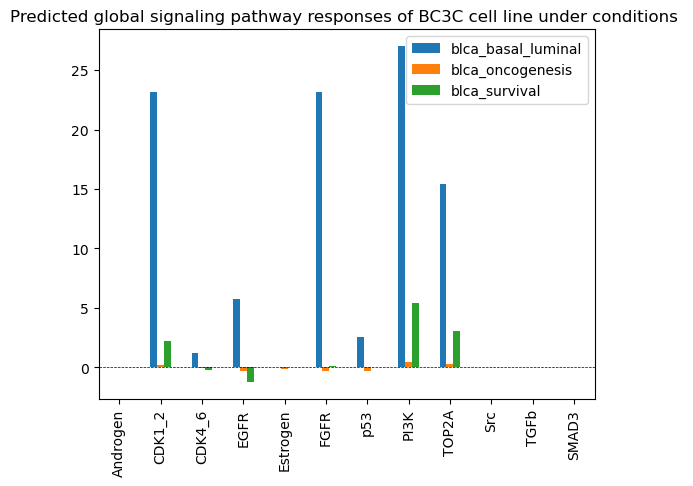

In [19]:
import matplotlib.pyplot as plt
t_df_subset.plot.bar()
plt.axhline(y=0, linestyle='--', color='black',linewidth=0.5)
plt.title(f"Predicted global signaling pathway responses of {cell_line} cell line under conditions ")

In [20]:
display(rm_filt)
rm_subset=rm_filt[['Androgen','CDK1_2', 'CDK4_6', 'EGFR', 'Estrogen', 'FGFR',
       'PI3K', 'p53', 'TOP2A','Src','TGFb']]

,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,-1.0,0.000000,0.000000,-0.045685,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
CDK1_2,0.0,-1.000000,0.000000,0.152190,0.000000,0.149464,0.237045,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
CDK4_6,0.0,0.000000,-1.000000,0.382667,0.000000,0.000000,0.150658,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
EGFR,0.0,0.000000,0.213246,-1.000000,0.000000,0.201551,-0.300184,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
Estrogen,0.0,0.000000,0.000000,0.000000,-1.000000,0.271996,0.138903,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
FGFR,0.0,0.000000,0.000000,0.377743,0.000000,-1.000000,0.133748,0.108073,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
PI3K,0.0,0.404411,0.000000,-0.204806,0.000000,0.000000,-1.000000,0.000000,0.570272,0.0,0.0,0.0,0.0,0.0,0.0
p53,0.0,0.000000,0.000000,0.221995,0.000000,0.000000,0.151450,-1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
TOP2A,0.0,0.000000,0.000000,-0.133707,0.000000,0.000000,0.168088,0.000000,-1.000000,0.0,0.0,0.0,0.0,0.0,0.0
Src,0.0,0.000000,0.000000,0.262256,0.537186,0.000000,0.000000,0.000000,0.000000,-1.0,0.0,0.0,0.0,0.0,0.0


In [21]:
rm_subset=rm_subset.loc[['blca_basal_luminal',	'blca_oncogenesis',	'blca_survival']]
rm_subset=rm_subset.T
display(rm_subset)

,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.000000,0.000000,0.000000
CDK1_2,12.262486,0.000000,0.000000
CDK4_6,0.000000,0.000000,0.000000
EGFR,0.000000,0.000000,0.000000
Estrogen,0.000000,-0.184305,0.000000
FGFR,18.569067,-0.257601,0.000000
PI3K,16.974607,0.360187,4.028788
p53,0.000000,-0.239053,0.000000
TOP2A,0.000000,0.000000,0.000000
Src,0.000000,0.000000,0.000000


Text(0.5, 1.0, 'Predicted local signaling pathway responses of BC3C cell line under conditions ')

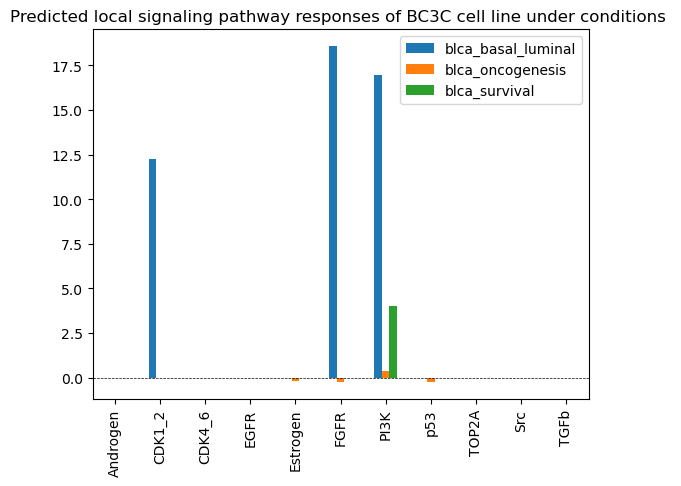

In [22]:
rm_subset.plot.bar()
plt.axhline(y=0, linestyle='--', color='black',linewidth=0.5)
plt.title(f"Predicted local signaling pathway responses of {cell_line} cell line under conditions ")